# iMUSH seismic phase picking with seisbench

Downloads waveform data from the **iMUSH** experiment (network code `XD`,
"Illuminating the architecture of the greater Mount St. Helens magmatic
systems from slab to surface", deployed 2014-2016) from EarthScope's FDSN
web services, runs deep-learning phase picking with
[seisbench](https://github.com/seisbench/seisbench)'s PhaseNet model, groups
the resulting picks into candidate events with a simple time-window
associator, and writes the result out as a JSON catalog.

> [!NOTE]
> iMUSH deployed over 5,000 nodes plus longer-running broadband stations
> across a 2014-2016 window, downloading continuous data for all of them is
> not something a notebook should attempt. This notebook downloads a single
> configurable time window from a configurable subset of stations instead.
> Widen `MAX_STATIONS` and the analysis window once you've confirmed the
> pipeline works for you.

> [!NOTE]
> The association step below is a **naive time-window heuristic**, not a
> physical locator. It groups picks that land close together in time across
> several stations, it does not compute a hypocenter, magnitude, or depth,
> which would need a velocity model and a real associator/locator (see
> "Next steps" at the end).


## Setup

In [1]:
import os

# Set before importing matplotlib: if $HOME/.cache (or $HOME/.config) isn't
# writable -- a stale/misconfigured persistent home volume, wrong ownership
# after an image or UID change, etc. -- matplotlib can fail to initialize
# its font/style cache. It usually just prints a warning and falls back to
# a temp dir, but plotting is more reliable if it never has to. /tmp is
# always writable in a container regardless of what $HOME looks like.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import json
from pathlib import Path

import matplotlib
matplotlib.use("Agg")  # see the note above the plotting cell below
import matplotlib.pyplot as plt
import seisbench.models as sbm
import torch
from IPython.display import Image, display
from obspy import Stream, UTCDateTime
from obspy.clients.fdsn import Client

print(f'seisbench GPU support: {torch.cuda.is_available()}')

Matplotlib is building the font cache; this may take a moment.


seisbench GPU support: False


## Configuration

In [2]:
# --- Data source -------------------------------------------------
NETWORK = "XD"  # iMUSH: EarthScope FDSN network code, deployed 2014-2016
CLIENT_URL = "https://service.earthscope.org"  # EarthScope FDSN web services (formerly IRIS DMC)

# --- Analysis window -----------------------------------------------
# A single hour within the iMUSH deployment. iMUSH's dense nodal array ran
# in short ~1-week bursts at different sites through 2014, while its
# broadband stations (the "M###"-style codes used below) ran continuously
# into 2016 -- pick any date in that broadband deployment window.
WINDOW_START = UTCDateTime("2014-08-01T00:00:00")
WINDOW_END = WINDOW_START + 3600  # one hour

# --- Station / channel selection ------------------------------------
# HH? = high-gain, ~100 Hz broadband channels -- the sample rate PhaseNet
# was trained on. Many iMUSH stations also carry a parallel LH? (1 Hz) band
# for long-period monitoring; that's far too coarse to resolve P/S arrivals,
# so it's deliberately excluded here rather than fed in alongside HH? and
# confusing the per-station 3-component grouping seisbench expects.
CHANNEL = "HH?"
MAX_STATIONS = 20

# --- Picking ----------------------------------------------------------
# PhaseNet (Zhu & Beroza, 2019) with the "volpick" pretrained weights,
# trained specifically on volcano-seismicity datasets -- a better match for
# a volcanic setting like Mount St. Helens than seisbench's generic
# tectonic-earthquake weight sets (e.g. "stead" or "original").
PHASENET_WEIGHTS = "volpick"
PICK_CONFIDENCE_THRESHOLD = 0.25

# --- Association --------------------------------------------------------
# Naive heuristic, see the note above: picks across at least
# MIN_STATIONS_PER_EVENT distinct stations, all within ASSOCIATION_WINDOW_SECONDS
# of each other, are grouped into one candidate event.
ASSOCIATION_WINDOW_SECONDS = 8.0
MIN_STATIONS_PER_EVENT = 3

CATALOG_PATH = Path("imush_catalog.json")


## Find active stations

In [3]:
client = Client(base_url=CLIENT_URL)

inventory = client.get_stations(
    network=NETWORK,
    channel=CHANNEL,
    starttime=WINDOW_START,
    endtime=WINDOW_END,
    level="channel",
)

all_stations = sorted({sta.code for net in inventory for sta in net})
stations = all_stations[:MAX_STATIONS]
print(f"{len(all_stations)} stations have {CHANNEL} data in this window; using {len(stations)}: {stations}")


71 stations have HH? data in this window; using 20: ['KRES', 'MA05', 'MB05', 'MB07', 'MC06', 'MC08', 'MD05', 'MD09', 'MD12', 'ME02', 'ME03', 'ME04', 'ME06', 'ME08', 'MF05', 'MF07', 'MF09', 'MG02', 'MG03', 'MG05']


## Download waveforms

In [4]:
st = Stream()
for sta in stations:
    try:
        st += client.get_waveforms(
            network=NETWORK, station=sta, location="*", channel=CHANNEL,
            starttime=WINDOW_START, endtime=WINDOW_END,
        )
    except Exception as exc:
        print(f"  skipping {sta}: {exc}")

st.merge(method=1, fill_value="interpolate")
stations_with_data = sorted({tr.stats.station for tr in st})
print(f"Downloaded {len(st)} traces from {len(stations_with_data)} stations: {stations_with_data}")


  skipping KRES: No data available for request.
HTTP Status code: 204
Detailed response of server:




  skipping MA05: No data available for request.
HTTP Status code: 204
Detailed response of server:




  skipping ME08: No data available for request.
HTTP Status code: 204
Detailed response of server:




Downloaded 51 traces from 17 stations: ['MB05', 'MB07', 'MC06', 'MC08', 'MD05', 'MD09', 'MD12', 'ME02', 'ME03', 'ME04', 'ME06', 'MF05', 'MF07', 'MF09', 'MG02', 'MG03', 'MG05']


## Pick seismic phases with seisbench

In [5]:
model = sbm.PhaseNet.from_pretrained(PHASENET_WEIGHTS)
if torch.cuda.is_available():
    model.cuda()
    print(f"Running PhaseNet ({PHASENET_WEIGHTS} weights) on: {torch.cuda.get_device_name(0)}")
else:
    print(f"No GPU available, running PhaseNet ({PHASENET_WEIGHTS} weights) on CPU")

output = model.classify(
    st,
    P_threshold=PICK_CONFIDENCE_THRESHOLD,
    S_threshold=PICK_CONFIDENCE_THRESHOLD,
)
picks = sorted(output.picks, key=lambda p: p.peak_time)
picked_stations = {p.trace_id.split(".")[1] for p in picks}
print(f"Found {len(picks)} phase picks across {len(picked_stations)} stations")


No GPU available, running PhaseNet (volpick weights) on CPU


Found 192 phase picks across 17 stations


## Associate picks into candidate events

Groups picks into a candidate event whenever at least `MIN_STATIONS_PER_EVENT`
distinct stations have a pick within `ASSOCIATION_WINDOW_SECONDS` of each
other. This is a naive greedy time-window clustering: it says "these arrivals
plausibly came from the same source", nothing more, it does **not** locate a
hypocenter. A real pipeline would hand these picks to a phase associator
(e.g. [PyOcto](https://github.com/yetinam/pyocto) or GaMMA) paired with a
velocity model to solve for location, depth, and origin time.


In [6]:
def cluster_stations(cluster):
    return {p.trace_id.split(".")[1] for p in cluster}


events = []
cluster = []
for pick in picks:
    if cluster and (pick.peak_time - cluster[-1].peak_time) > ASSOCIATION_WINDOW_SECONDS:
        if len(cluster_stations(cluster)) >= MIN_STATIONS_PER_EVENT:
            events.append(cluster)
        cluster = []
    cluster.append(pick)
if cluster and len(cluster_stations(cluster)) >= MIN_STATIONS_PER_EVENT:
    events.append(cluster)

print(f"Grouped {len(picks)} picks into {len(events)} candidate events "
      f"(>= {MIN_STATIONS_PER_EVENT} stations within {ASSOCIATION_WINDOW_SECONDS}s)")


Grouped 192 picks into 9 candidate events (>= 3 stations within 8.0s)


## Build and save the JSON catalog

In [7]:
def pick_to_dict(pick):
    network, station = pick.trace_id.split(".")[:2]
    return {
        "network": network,
        "station": station,
        "phase": pick.phase,
        "time": pick.peak_time.isoformat(),
        "confidence": round(float(pick.peak_value), 4) if pick.peak_value is not None else None,
    }


catalog = {
    "source": {
        "network": NETWORK,
        "client": CLIENT_URL,
        "channel": CHANNEL,
        "window_start": WINDOW_START.isoformat(),
        "window_end": WINDOW_END.isoformat(),
    },
    "model": {
        "name": "PhaseNet",
        "weights": PHASENET_WEIGHTS,
        "threshold": PICK_CONFIDENCE_THRESHOLD,
    },
    "association": {
        "method": "naive time-window clustering (not a physical locator)",
        "window_seconds": ASSOCIATION_WINDOW_SECONDS,
        "min_stations": MIN_STATIONS_PER_EVENT,
    },
    "events": [
        {
            "event_id": i,
            "time": min(p.peak_time for p in cluster).isoformat(),
            "num_picks": len(cluster),
            "num_stations": len(cluster_stations(cluster)),
            "picks": [pick_to_dict(p) for p in cluster],
        }
        for i, cluster in enumerate(events, start=1)
    ],
}

CATALOG_PATH.write_text(json.dumps(catalog, indent=2))
print(f"Wrote {len(catalog['events'])} events to {CATALOG_PATH}")
catalog["events"][:2]  # preview the first couple of events


Wrote 9 events to imush_catalog.json


[{'event_id': 1,
  'time': '2014-08-01T00:03:54.345000',
  'num_picks': 4,
  'num_stations': 3,
  'picks': [{'network': 'XD',
    'station': 'MB07',
    'phase': 'S',
    'time': '2014-08-01T00:03:54.345000',
    'confidence': 0.2779},
   {'network': 'XD',
    'station': 'MG05',
    'phase': 'P',
    'time': '2014-08-01T00:03:57.575000',
    'confidence': 0.2979},
   {'network': 'XD',
    'station': 'MG05',
    'phase': 'S',
    'time': '2014-08-01T00:04:02.185000',
    'confidence': 0.3923},
   {'network': 'XD',
    'station': 'ME02',
    'phase': 'P',
    'time': '2014-08-01T00:04:06.985000',
    'confidence': 0.3737}]},
 {'event_id': 2,
  'time': '2014-08-01T00:17:54.780000',
  'num_picks': 4,
  'num_stations': 3,
  'picks': [{'network': 'XD',
    'station': 'MG03',
    'phase': 'P',
    'time': '2014-08-01T00:17:54.780000',
    'confidence': 0.3568},
   {'network': 'XD',
    'station': 'ME06',
    'phase': 'P',
    'time': '2014-08-01T00:17:55.105000',
    'confidence': 0.2762},
  

## Visualize every candidate event

Plots the Z-component waveform at each contributing station for every event
in the catalog, with vertical lines marking the P (blue) and S (red) picks
that put it there. With a lot of events this cell prints a lot of output,
narrow the analysis window or raise `MIN_STATIONS_PER_EVENT` above if that's
not what you want.

> [!NOTE]
> This renders each plot by saving it to a PNG and displaying that with
> `IPython.display.Image`, instead of `plt.show()`. `plt.show()` depends on
> the kernel's matplotlib backend actually being wired up for inline
> display, and on at least one real JupyterLab session that wasn't
> reliably true even with `%matplotlib inline` set, while a bare
> `Image(path)` renders regardless. If `plt.show()` works fine in your own
> session, both approaches look identical, this one just also works when
> it doesn't.

9 candidate event(s) to plot


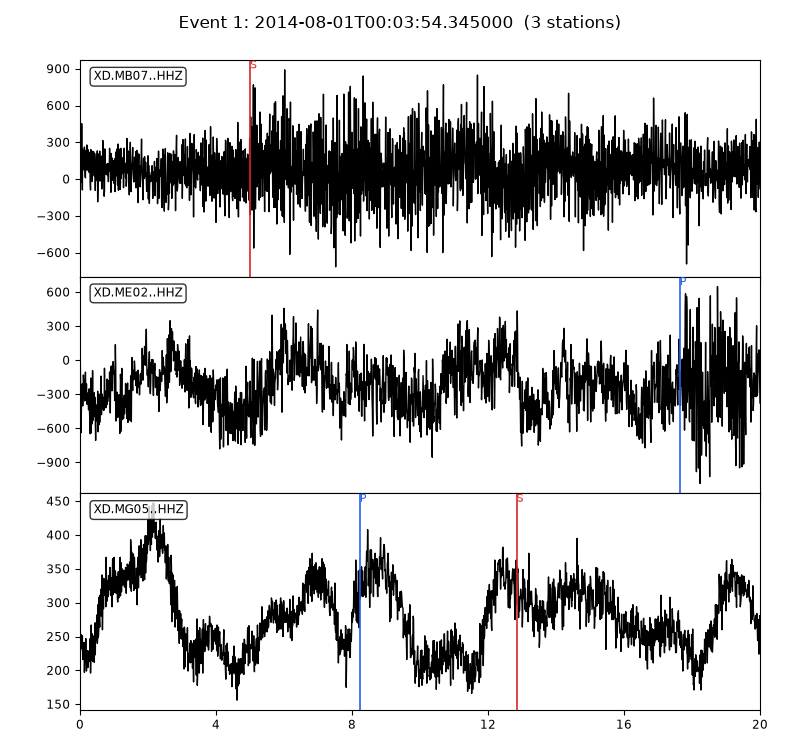

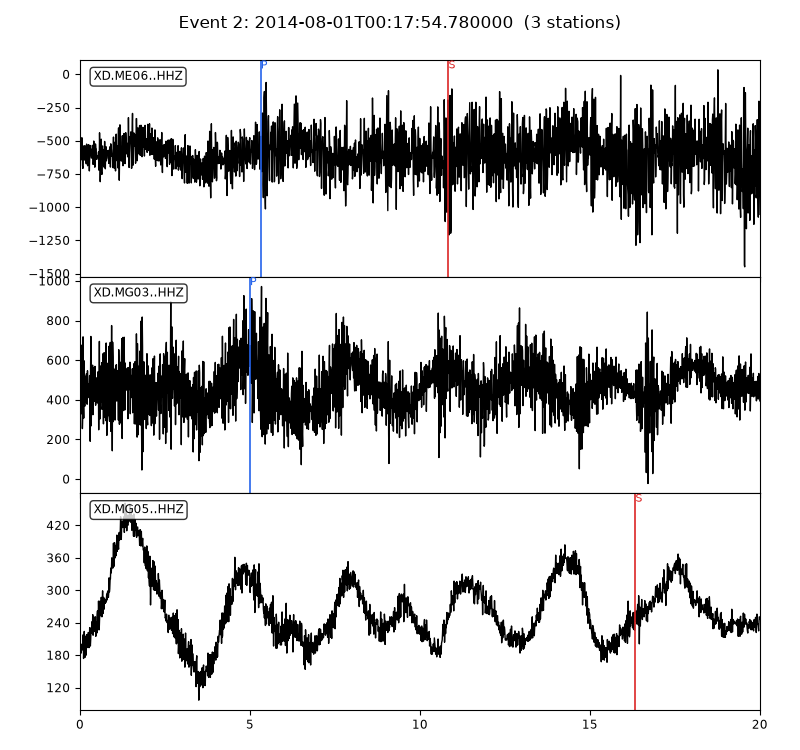

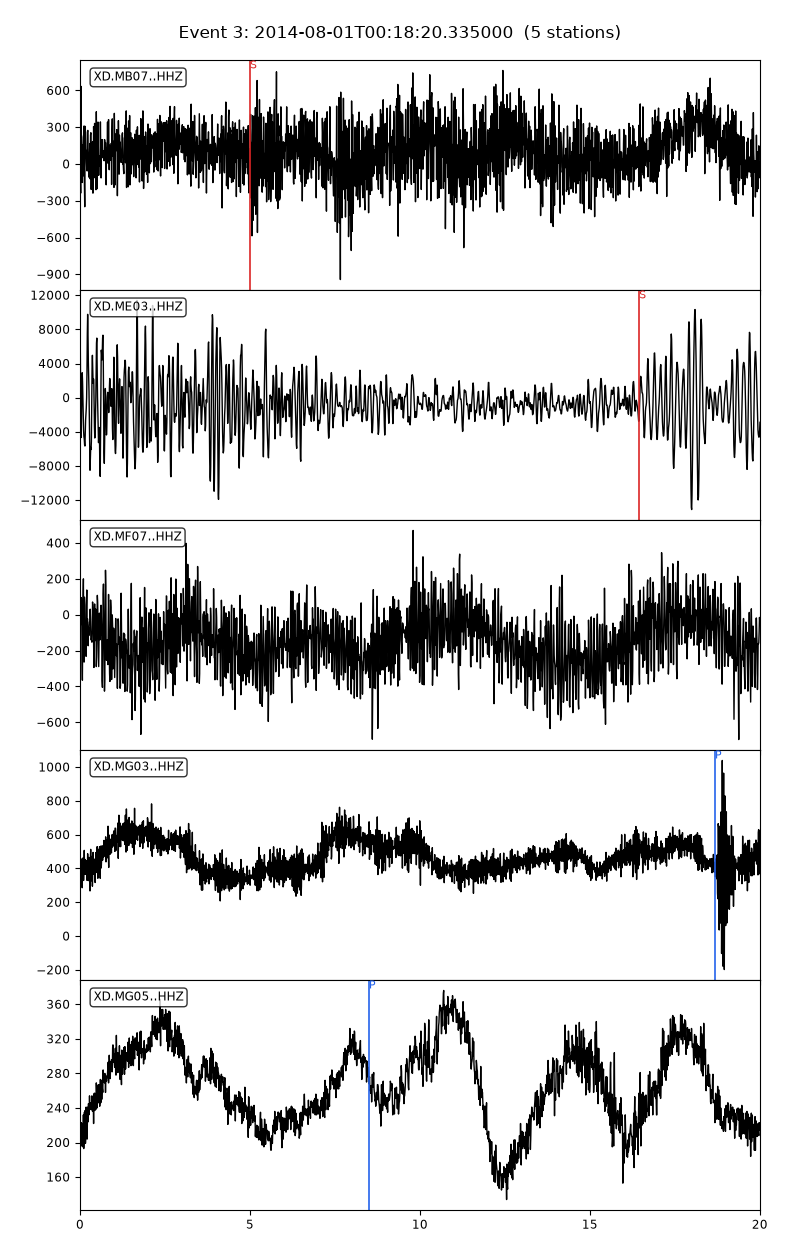

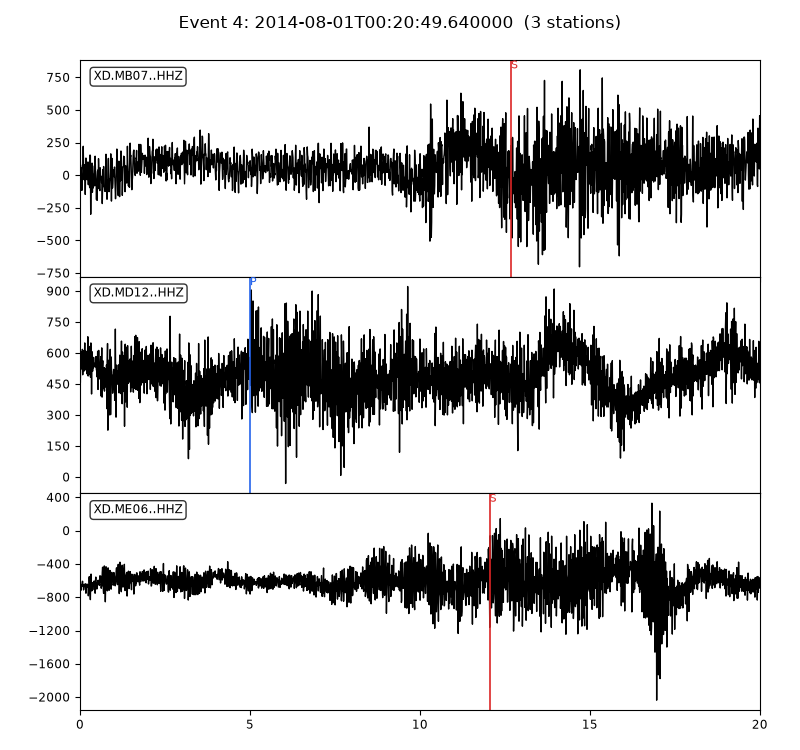

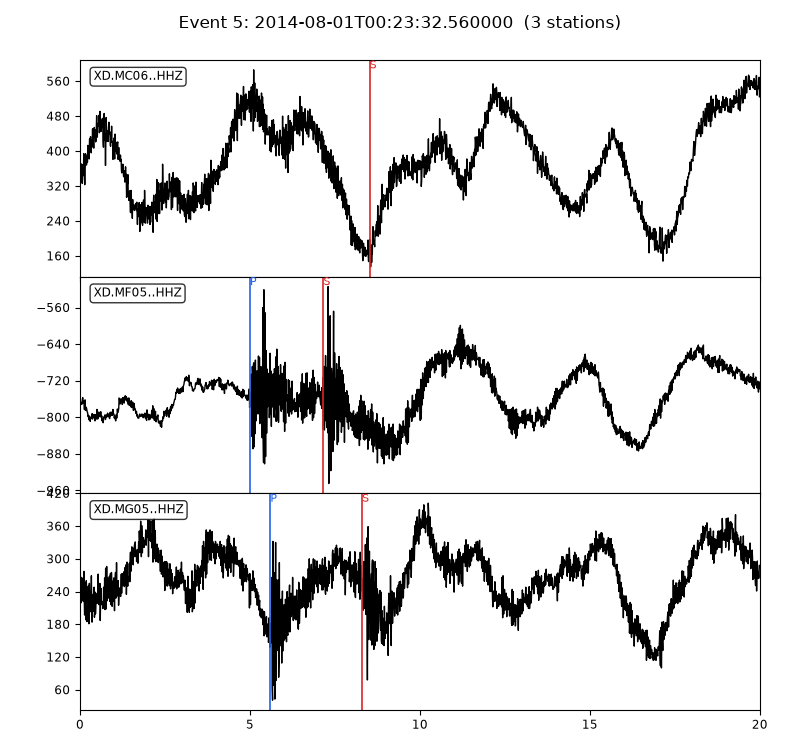

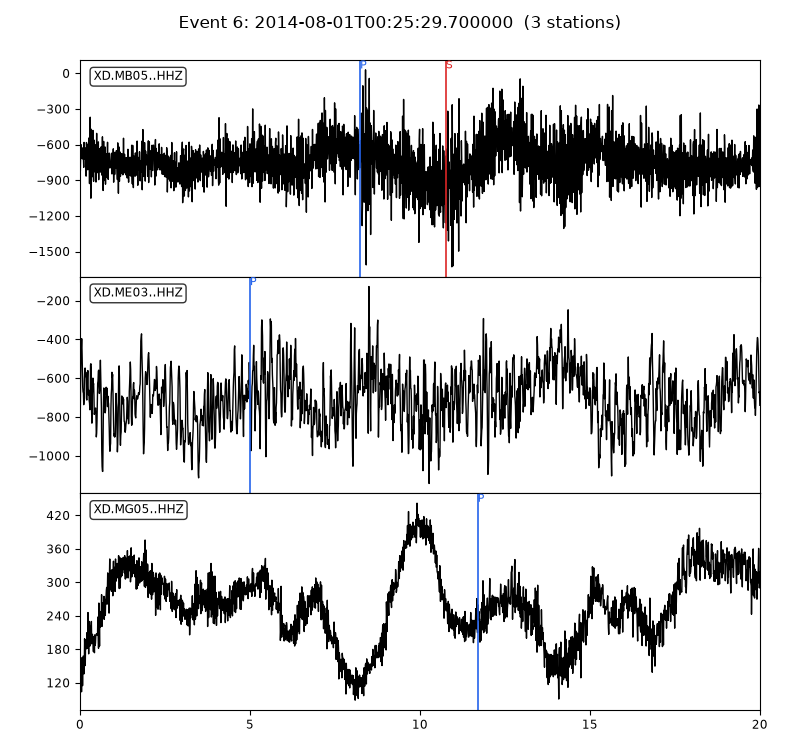

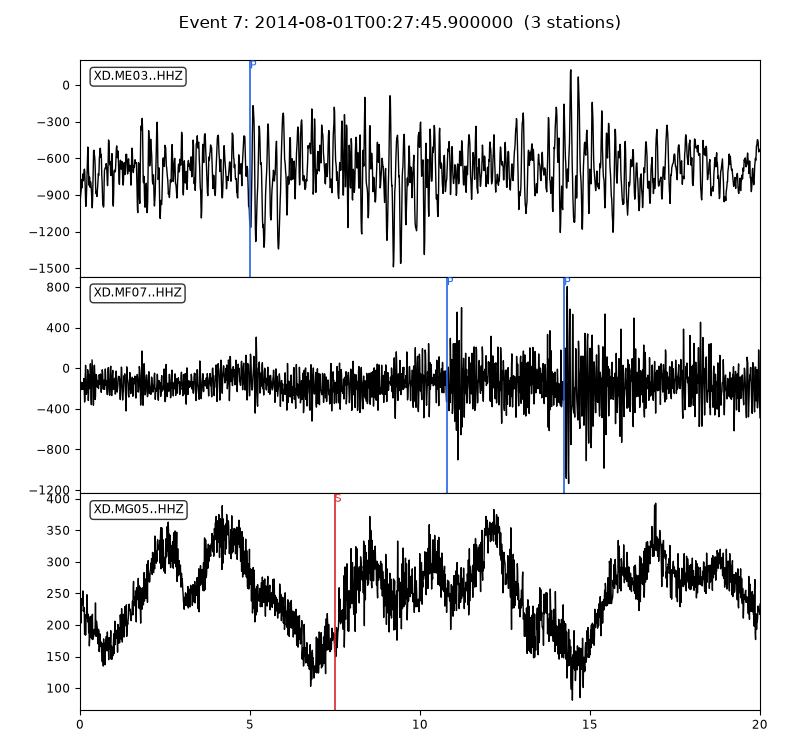

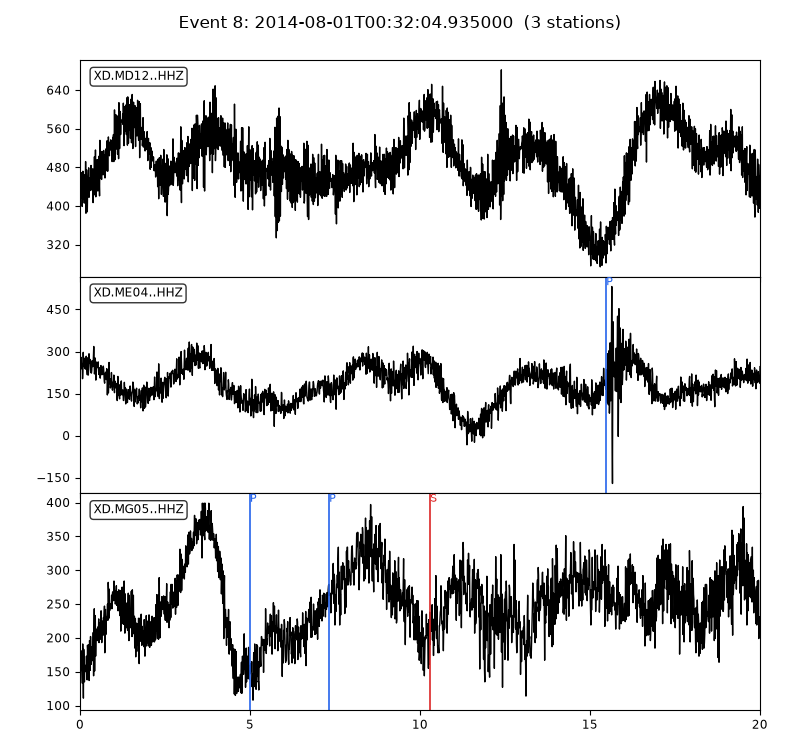

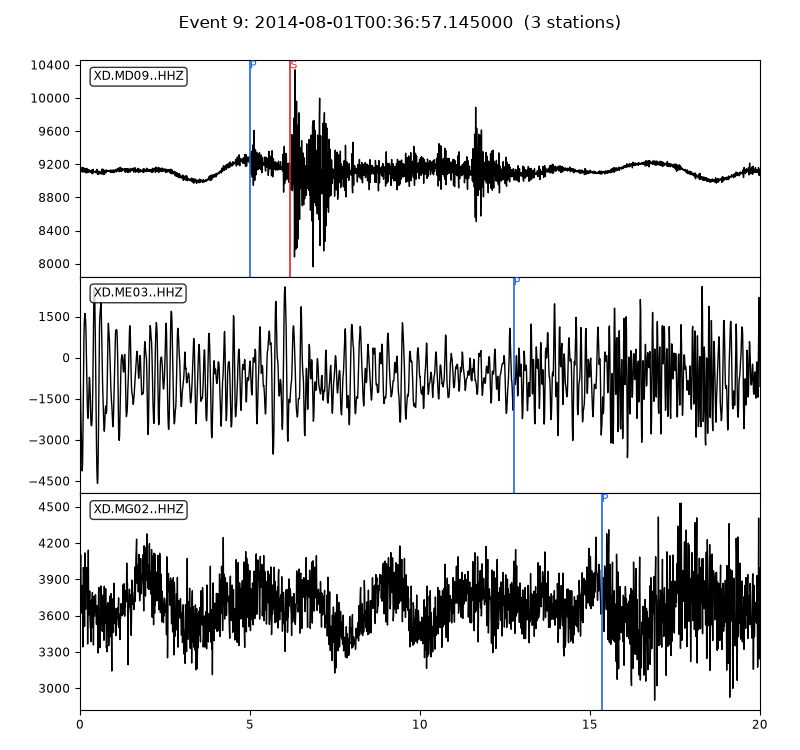

Plotted 9 events.


In [8]:
EVENT_PLOT_DIR = Path("/tmp/imush_event_plots")
EVENT_PLOT_DIR.mkdir(exist_ok=True)


def plot_event(event, stream):
    """Build a small Stream (one Z trace per contributing station, trimmed
    to the event window) and let ObsPy's own Stream.plot() draw it -- one
    stacked subplot per trace, labeled with its NET.STA..CHAN id, with a
    consistent time axis. Pick markers are then overlaid on the axes
    ObsPy hands back (`handle=True, show=False` returns the Figure instead
    of displaying/blocking, so we can finish annotating before saving it)."""
    event_time = UTCDateTime(event["time"])
    stations_in_event = sorted({p["station"] for p in event["picks"]})

    sub = Stream()
    for sta in stations_in_event:
        # component="Z" matches the vertical trace regardless of band code
        # (HHZ, EHZ, BHZ, ...) -- more robust than hardcoding one, and
        # tolerates a station that's missing its Z trace instead of raising.
        traces = stream.select(station=sta, component="Z")
        if not traces:
            print(f"  event {event['event_id']}: no Z trace for {sta}, skipping")
            continue
        tr = traces[0].copy()
        tr.trim(event_time - 5, event_time + 15)
        sub += tr

    if len(sub) == 0:
        print(f"Event {event['event_id']}: no plottable traces")
        return None

    fig = sub.plot(handle=True, show=False, type="relative", equal_scale=False)

    # type="relative" puts each trace's own start at x=0, so a pick's
    # x-position is its offset from that *trace's* (post-trim) start time,
    # not from event_time -- using tr.stats.starttime here keeps that
    # correct even if traces don't all start at exactly the same sample.
    for ax, tr in zip(fig.axes, sub):
        for pick in event["picks"]:
            if pick["station"] != tr.stats.station:
                continue
            t = UTCDateTime(pick["time"]) - tr.stats.starttime
            color = "#2563eb" if pick["phase"] == "P" else "#dc2626"
            ax.axvline(t, color=color, linewidth=1.2)
            ax.annotate(pick["phase"], (t, ax.get_ylim()[1]), color=color, fontsize=8, va="top")

    fig.suptitle(f"Event {event['event_id']}: {event['time']}  ({event['num_stations']} stations)")
    return fig


print(f"{len(catalog['events'])} candidate event(s) to plot")

if catalog["events"]:
    for event in catalog["events"]:
        fig = plot_event(event, st)
        if fig is not None:
            out_path = EVENT_PLOT_DIR / f"event_{event['event_id']}.png"
            fig.savefig(out_path, dpi=100)
            plt.close(fig)
            display(Image(filename=str(out_path)))
    print(f"Plotted {len(catalog['events'])} events.")
else:
    print("No candidate events in this window, try widening the analysis window, "
          "lowering PICK_CONFIDENCE_THRESHOLD, or increasing MAX_STATIONS.")

## Next steps

- **Widen the scope.** Increase `MAX_STATIONS`, lengthen the analysis
  window, or loop this notebook over multiple windows/days across the full
  2014-2016 deployment.
- **Use a real associator.** Swap the naive clustering above for
  [PyOcto](https://github.com/yetinam/pyocto) or GaMMA, paired with a
  regional velocity model, to get an actual hypocenter, depth, and origin
  time per event instead of just a pick cluster.
- **Estimate magnitude.** None of the fields here include a magnitude,
  that needs amplitude measurements and a calibrated magnitude relation,
  not just phase arrival times.
